<a href="https://colab.research.google.com/github/paddydoc/paddy-doctor-dataset/blob/main/notebooks/cnn_diseases_small_400_split_epoch100.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## This notebook demonstrates how to develop a simple deep CNN model for paddy disease classition using Keras.

### Sections of this notebook
1. [Setup environment and import datasets](#setup)
2. [Import libraries](#import)
3. [Dataset preparation](#dataset)
3. [Define a deep CNN model](#model)
4. [Model training](#train)
5. [Model testing](#test)
6. [Results](#results)

<a name="setup"></a>
### 1. Setup environment and import datasets


<!-- ####  a. Import dataset

1. Download the Paddy Doctor split balanced dataset file ``paddy-doctor-diseases-small-400-split.zip`` from [this link](https://ieee-dataport.org/documents/paddy-doctor-visual-image-dataset-automated-paddy-disease-classification-and-benchmarking)
2. Create a new folder named ``paddy-doctor`` in your Google Drive's root directory and upload the ``paddy-doctor-diseases-small-400-split.zip`` file there. -->

#### b. Mount Google Drive


In [ ]:
# ## mount google drive
# from google.colab import drive
# drive.mount('/content/drive')
# !pwd

In [ ]:
# %cd /content/drive/MyDrive/paddy-doctor
# !ls -l

#### c. Extract the datset files

In [ ]:
# ## skip this command, if you already have extracted the files
# #!unzip -qq paddy-doctor-diseases-small-splitted.zip
# !unzip -qq paddy-doctor-diseases-small-400-split.zip

##### The ``paddy-doctor`` folder should contains the following directories and files.

In [ ]:
# !ls -l
# !find ./train -type f -print | wc -l
# !find ./test -type f -print | wc -l

<a name="import"></a>
### 2. Import python *libraries*


#### Verify the files in the train and test directories

In [ ]:
# import glob
# from pathlib import Path

# ## Google Colab (See the above instructions)
# # train_path = '/content/drive/MyDrive/paddy-doctor/train/'
# # test_path  = '/content/drive/MyDrive/paddy-doctor/test/'

# ## Kaggle (create a new dataset with a path "paddy-doctor-diseases-small-400-split" using paddy-doctor-diseases-small-400-split.zip

# train_path = '/kaggle/input/paddy-doctor-disease/split/kaggle/working/paddy-doctor-disease/paddy-doctor-diseases-small_split_400/train/'
# test_path  = '/kaggle/input/paddy-doctor-disease/split/kaggle/working/paddy-doctor-disease/paddy-doctor-diseases-small_split_400/test/'

# print('training set')
# for filepath in glob.glob(train_path + '/*/'):
#     files = glob.glob(filepath + '*')
#     print(f"{len(files)} \t {Path(filepath).name}")

# print('testing set')
# for filepath in glob.glob(test_path + '/*/'):
#     files = glob.glob(filepath + '*')
#     print(f"{len(files)} \t {Path(filepath).name}")

In [1]:
import glob

try: import fastkaggle
except ModuleNotFoundError:
    !pip install -Uq fastkaggle

from fastkaggle import *
from fastai.vision.all import *
set_seed(42)

#/kaggle/input/paddy-doctor-diseases-small-400-split

competition = '/kaggle/input/paddy-doctor-disease/Augmented and split - 26000 augmented images split into train (80) sets'
path = setup_comp(competition, install='fastai "timm>=0.6.2.dev0"')
print(path)

# train images
train_path = path / 'train'
train_files = get_image_files(train_path)

# test images
test_path = path/'test'
test_files = get_image_files(test_path).sorted()

# train labels
train_df = pd.read_csv(path / 'metadata-train.csv')
print(train_df.shape)
train_df.label.value_counts()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.8/234.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 31.9 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pylibcugraph-cu12 24.12.0 requires pylibraft-cu12==24.12.*, but you have pylibraft-cu12 25.2.0 which is incompatible.
pylibcugraph-cu12 24.12.0 requires rmm-cu12==24.12.*, but you have rmm-cu12 25.2.0 which is incompatible.


/kaggle/input/paddy-doctor-disease/Augmented and split - 26000 augmented images split into train (80) sets
(20800, 4)


label
brown_spot                  1601
downy_mildew                1601
white_stem_borer            1601
bacterial_leaf_streak       1600
black_stem_borer            1600
blast                       1600
hispa                       1600
leaf_roller                 1600
tungro                      1600
yellow_stem_borer           1600
bacterial_leaf_blight       1599
bacterial_panicle_blight    1599
normal                      1599
Name: count, dtype: int64

In [2]:
# dblock = DataBlock(
#     blocks=(ImageBlock, CategoryBlock),
#     get_items=get_image_files,
#     get_y=parent_label,
#     splitter=RandomSplitter(0.2, seed=42),
#     item_tfms=Resize(480, method='squish'),
#     batch_tfms=aug_transforms(size=224, min_scale=0.75)
# )


dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=parent_label,
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    item_tfms=Resize(480, method='squish'),
    batch_tfms=aug_transforms(
        size=224, 
        min_scale=0.85,
        max_rotate=15,      # Increased rotation range
        max_zoom=1.1,       # Increased zoom range
        max_warp=0.1,       # Allow for warping
        p_affine=0.75,      # Probability for affine transforms
        p_lighting=0.75     # Probability for lighting transforms
    ) + [RandomErasing(p=0.4, max_count=1)]  # Randomly erase part of the image for extra robustness
)

dls = dblock.dataloaders(train_path)

In [3]:
# dls = ImageDataLoaders.from_folder(
#     train_path, 
#     valid_pct=0.2,
#     seed=42,
#     item_tfms=Resize(480, method='squish'),
#     batch_tfms=aug_transforms(size=224, min_scale=0.75)
# )

In [4]:
# pip install timm

In [5]:
# # Use wandb? Resume Training?
# USE_WANDB = config['wandb']

# RESUME_LOGGING = False # Set this to true if you are resuming training from a previous run

# # Create your wandb run
# if wandb.run is not None:
#     print("Closing existing WandB run...")
#     wandb.run.finish()
    
# run_name = '{}_early_submission'.format(config['Name'])

# # If you are resuming an old run
# if USE_WANDB:

#     wandb.login(key="f54d876ebca391d5a1ed3eebb7a43aa7bea9da21") #TODO

#     if RESUME_LOGGING:
#         run = wandb.init(
#             id     = "", ### Insert specific run id here if you want to resume a previous run
#             resume = "must", ### You need this to resume previous runs
#             project = "project-ablations", ### Project should be created in your wandb
#             settings = wandb.Settings(_service_wait=300)
#         )


#     else:
#         run = wandb.init(
#             name    = run_name, ### Wandb creates random run names if you skip this field, we recommend you give useful names
#             reinit  = True, ### Allows reinitalizing runs when you re-run this cell
#             project = "project-ablations", ### Project should be created in your wandb account
#             config  = config ### Wandb Config for your run
#         )

#         ### Save your model architecture as a string with str(model)
#         model_arch  = str(model)
#         ### Save it in a txt file
#         arch_file   = open("model_arch.txt", "w")
#         file_write  = arch_file.write(model_arch)
#         arch_file.close()

#         ### log it in your wandb run with wandb.save()
#         wandb.save('model_arch.txt')

In [6]:
# from timm import create_model
# from fastai.vision.all import vision_learner, error_rate


# def efficientnet_model(**kwargs):
#     # Remove any pretrained argument passed from Fastai
#     kwargs.pop('pretrained', None)
#     return create_model("tf_efficientnet_b0_ns", pretrained=True, **kwargs)

# # learn = vision_learner(dls, efficientnet_model, metrics=error_rate).to_fp16()

# # Create a vision learner with the MixUp callback and convert to FP16.
# learn_eff = vision_learner(
#     dls, efficientnet_model, metrics=error_rate,
#     cbs=[
#         MixUp(),
#         SaveModelCallback(fname='eff_best_model', monitor='error_rate'),
#         WandbCallback(log_model=True)
#     ]
# ).to_fp16()

# # Optionally, run the learning rate finder to choose an optimal learning rate.
# # lr_min, lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))
# # print(f"Suggested Learning Rates: {lr_min:.2e}, {lr_steep:.2e}")

In [7]:
# %%timeit
# # learn.fine_tune(10, 0.005)

# # Fine-tune the model:
# # - 20 epochs for a longer training period.
# # - Use weight decay (wd) for regularization.
# learn_eff.fine_tune(20, base_lr=0.005, wd=0.01)

In [8]:
import wandb

wandb.login(key="f54d876ebca391d5a1ed3eebb7a43aa7bea9da21")

run = wandb.init(
    project="project-ablations",  # Customize as needed
    name="efficientnet_resnet_ensemble",
    config={
        "epochs": 20,
        "base_lr": 0.005,
        "weight_decay": 0.01,
        "architecture": "EfficientNet + ResNet50 Ensemble"
    },
    reinit=True
)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nigibril1 (nigibril1-gibril-tech) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


In [9]:
from timm import create_model
from fastai.vision.all import vision_learner, error_rate, accuracy, MixUp, SaveModelCallback
from fastai.callback.wandb import WandbCallback
from fastai.callback.schedule import ParamScheduler, combine_scheds, SchedCos
from fastai.callback.tracker import ReduceLROnPlateau, EarlyStoppingCallback

# -----------------------------
# EfficientNet Learner
# -----------------------------
wandb.init(project="crop-recommendation-ensemble", name="EfficientNet_Run") 
def efficientnet_model(**kwargs):
    kwargs.pop('pretrained', None)
    return create_model("tf_efficientnet_b0_ns", pretrained=True, **kwargs)

learn_eff = vision_learner(
    dls, efficientnet_model, metrics=[accuracy, error_rate],
    cbs=[
        MixUp(),  # Data augmentation
        SaveModelCallback(fname='eff_best_model', monitor='error_rate'),
        ParamScheduler({'lr': combine_scheds(
            [0.3, 0.7],
            [SchedCos(0.005, 0.01), SchedCos(0.01, 1e-4)]
        )}),
        ReduceLROnPlateau(monitor='valid_loss', patience=2),
        EarlyStoppingCallback(monitor='valid_loss', patience=5),
        WandbCallback(log_model=True)
    ]
).to_fp16()
learn_eff.model_dir = "/kaggle/working/models"

# -----------------------------
# ResNet50 Learner
# -----------------------------
wandb.init(project="crop-recommendation-ensemble", name="ResNet_Run")

def resnet_model(**kwargs):
    kwargs.pop('pretrained', None)
    return create_model("resnet50", pretrained=True, **kwargs)

learn_resnet = vision_learner(
    dls, resnet_model, metrics=[accuracy, error_rate],
    cbs=[
        MixUp(),
        SaveModelCallback(fname='resnet_best_model', monitor='error_rate'),
        ParamScheduler({'lr': combine_scheds(
            [0.3, 0.7],
            [SchedCos(0.005, 0.01), SchedCos(0.01, 1e-4)]
        )}),
        ReduceLROnPlateau(monitor='valid_loss', patience=2),
        EarlyStoppingCallback(monitor='valid_loss', patience=5),
        WandbCallback(log_model=True)
    ]
).to_fp16()
learn_resnet.model_dir = "/kaggle/working/models"

# -----------------------------
# [Optional] Load previously saved models
# -----------------------------
# Uncomment these lines ONLY if you want to reload the trained models
# learn_eff = load_learner("/kaggle/working/models/eff_best_model.pkl")
# learn_resnet = load_learner("/kaggle/working/models/resnet_best_model.pkl")

/usr/local/lib/python3.11/dist-packages/timm/models/_factory.py:126: UserWarning: Mapping deprecated model name tf_efficientnet_b0_ns to current tf_efficientnet_b0.ns_jft_in1k.
  model = create_fn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [ ]:
# %%timeit

learn_eff.fine_tune(20, base_lr=0.005, wd=0.01)
learn_resnet.fine_tune(20, base_lr=0.005, wd=0.01)

/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.11/dist-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/fastai/callback/fp16.py:47: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.autocast,self.learn.scaler,self.scales = autocast(dtype=dtype),GradScaler(**self.kwargs),L()
/usr/local/lib/python3.11/dist-packages/torch/amp/grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,2.457934,1.818116,0.408173,0.591827,41:45


Better model found at epoch 0 with error_rate value: 0.5918269157409668.


/usr/local/lib/python3.11/dist-packages/fastai/learner.py:53: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  elif device is None: device = 'cpu'


epoch,train_loss,valid_loss,accuracy,error_rate,time
0,2.033252,1.524466,0.514904,0.485096,53:24


Better model found at epoch 0 with error_rate value: 0.48509615659713745.


In [9]:
learn_eff.export("eff_final_model.pkl")
learn_resnet.export("resnet_final_model.pkl")

wandb.save("eff_final_model.pkl")
wandb.save("resnet_final_model.pkl")

NameError: name 'learn_eff' is not defined

In [38]:
# %%timeit
# learn.fine_tune(10, 0.005)

**Model predictions**

In [39]:
# Get predictions on validation set
# probs, target = learn.get_preds(dl=dls.valid)
# error_rate(probs, target)
# -----------------------------
# Ensemble Predictions with TTA
# -----------------------------
probs_eff, target = learn_eff.tta(dl=dls.valid)
probs_resnet, _ = learn_resnet.tta(dl=dls.valid)

ensemble_probs = (probs_eff + probs_resnet) / 2
print("Ensembled Error Rate (Validation):", error_rate(ensemble_probs, target))

Ensembled Error Rate (Validation): TensorBase(0.1575)


In [ ]:
ensemble_val_error = error_rate(ensemble_probs, target)
wandb.log({"ensemble_val_error_rate": ensemble_val_error})

In [40]:
# Get TTA predictions on validation set
# probs, target = learn.tta(dl=dls.valid)
# error_rate(probs, target)

In [41]:
# test images
# test_path = path/'test'
# test_files = get_image_files(test_path).sorted()
# test_classes = [f.parent.name for f in test_files]

# probs, _ = learn.tta(dl=dls.test_dl(test_files))
# preds = probs.argmax(dim=1)
# pred_classes = dls.vocab[preds]

# -----------------------------
# Ensemble on Test Set
# -----------------------------
test_path = path/'test'
test_files = get_image_files(test_path).sorted()
test_classes = [f.parent.name for f in test_files]

probs_eff_test, _ = learn_eff.tta(dl=dls.test_dl(test_files))
probs_resnet_test, _ = learn_resnet.tta(dl=dls.test_dl(test_files))

ensemble_test_probs = (probs_eff_test + probs_resnet_test) / 2
preds = ensemble_test_probs.argmax(dim=1)
pred_classes = dls.vocab[preds]

**Results**

In [42]:
# from sklearn.metrics import classification_report
# from sklearn.metrics import accuracy_score

# cls_report = classification_report(test_classes, pred_classes, 
#                                    digits=5)
# print(cls_report)
# acc = accuracy_score(test_classes, pred_classes)

# -----------------------------
# Metrics and Report
# -----------------------------
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

cls_report = classification_report(test_classes, pred_classes, digits=5)
print(cls_report)

acc = accuracy_score(test_classes, pred_classes)
print(f"Ensemble Accuracy on Test Set: {acc:.5f}")

                          precision    recall  f1-score   support

   bacterial_leaf_blight    0.82759   0.90000   0.86228        80
   bacterial_leaf_streak    0.89655   0.97500   0.93413        80
bacterial_panicle_blight    0.93671   0.92500   0.93082        80
        black_stem_borer    0.92683   0.95000   0.93827        80
                   blast    0.79268   0.81250   0.80247        80
              brown_spot    0.90323   0.70000   0.78873        80
            downy_mildew    0.83951   0.85000   0.84472        80
                   hispa    0.72500   0.72500   0.72500        80
             leaf_roller    0.80000   0.85000   0.82424        80
                  normal    0.82022   0.91250   0.86391        80
                  tungro    0.89706   0.76250   0.82432        80
        white_stem_borer    0.87671   0.80000   0.83660        80
       yellow_stem_borer    0.90588   0.96250   0.93333        80

                accuracy                        0.85577      1040
        

In [ ]:
import wandb
wandb.log({"ensemble_test_accuracy": acc})

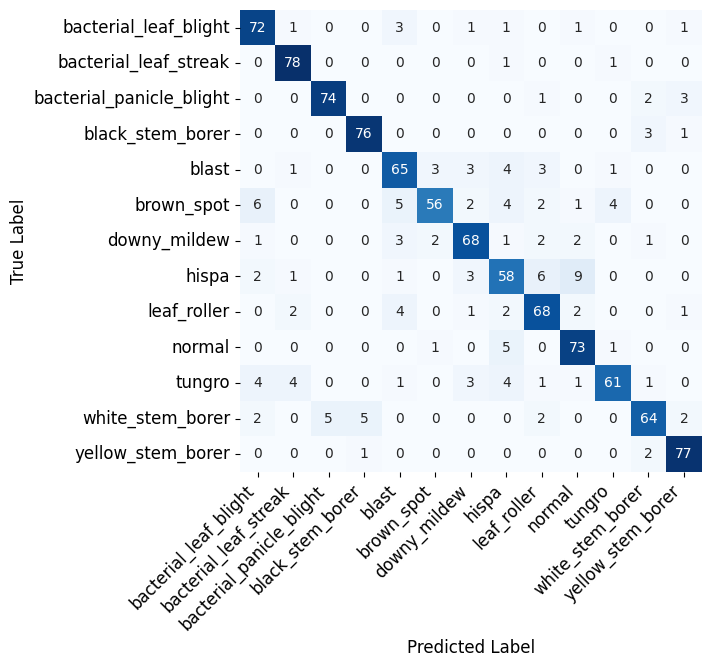

In [19]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# def plot_heatmap(y_true, y_pred, class_names, ax, title):
#     cm = confusion_matrix(y_true, y_pred)
#     sns.heatmap(
#         cm, 
#         annot=True, 
#         square=True, 
#         xticklabels=class_names, 
#         yticklabels=class_names,
#         fmt='d', 
#         cmap=plt.cm.Blues,
#         cbar=False,
#         ax=ax
#     )
#     #ax.set_title(title, fontsize=16)
#     ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=45, ha="right")
#     ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
#     ax.set_ylabel('True Label', fontsize=12)
#     ax.set_xlabel('Predicted Label', fontsize=12)

# fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# class_names = dls.vocab
# plot_heatmap(test_classes, pred_classes, class_names, ax, title="Resnet34")   


# #fig.suptitle("Confusion Matrix Model Comparison", fontsize=12)
# #fig.tight_layout()
# #fig.subplots_adjust(top=1.25)
# plt.show()
# cm = confusion_matrix(test_classes, pred_classes)
# print(cm)


# -----------------------------
# Confusion Matrix Plot
# -----------------------------
def plot_heatmap(y_true, y_pred, class_names, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, 
        annot=True, 
        square=True, 
        xticklabels=class_names, 
        yticklabels=class_names,
        fmt='d', 
        cmap=plt.cm.Blues,
        cbar=False,
        ax=ax
    )
    ax.set_xticklabels(ax.get_xticklabels(), fontsize=12, rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plot_heatmap(test_classes, pred_classes, dls.vocab, ax, title="Ensembled EfficientNet + ResNet50")
plt.show()

In [ ]:
# res = pd.DataFrame({"y_true":test_classes,
#                       "y_pred":pred_classes})
# res.to_csv('result.csv', index=False)
# res


# -----------------------------
# Save Results
# -----------------------------
res = pd.DataFrame({
    "y_true": test_classes,
    "y_pred": pred_classes
})
res.to_csv('result.csv', index=False)
res